# Financial Sustainability Dataset — Exploratory Data Analysis & Unsupervised Learning

This notebook walks through a complete, end-to-end analysis of `financial_sustainability.csv`:

1. **Data Import** — load and structurally inspect the raw file
2. **Exploratory Data Analysis (EDA)** — distributions, missingness, outliers, correlations, geography
3. **EDA Findings** — plain-English write-up of what stage 2 revealed
4. **Unsupervised Learning** — PCA, K-Means, hierarchical clustering, and DBSCAN, built directly on the EDA findings
5. **Unsupervised Learning Findings** — plain-English write-up of what the clustering revealed
6. **Composite Financial Stability Score & Fragility Metrics** — derived, decision-ready features built from the PCA/clustering output, for scoring and monitoring counties going forward
7. **Composite Score & Fragility Findings** — plain-English write-up of what those derived features reveal
8. **Final Report** — a consolidated, plain-English summary of the whole analysis

Every "findings" section is written to be readable by someone with no statistics background.

## 1. Data Import

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage

%matplotlib inline
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)

RANDOM_STATE = 42

In [2]:
raw = pd.read_csv("financial_sustainability.csv", index_col=0)
print("Shape (rows, columns):", raw.shape)
raw.head()

Shape (rows, columns): (40409, 16)


,State Name,County Name,City Name,5fipscode,9fipscode,UnempRte,MedHouseIncome,jobs_total_5mi_2015,ann_avg_job_growth_2004_2013,job_density_2013,employ_rate,P_less_30k,P_more_200,QOL_index,shrunk_xkid_vscore2020,shrunk_xkid_brcbalance2020
0,ALABAMA,AUTAUGA,AUTAUGAVILLE,1001.0,10010220.0,0.021889,68857.0,6825.416667,-0.008594,242.705151,74.127066,28.92907,1.733049,59.143956,652.103051,4007.485497
1,ALABAMA,AUTAUGA,BILLINGSLEY,1001.0,10010340.0,0.021889,68857.0,6825.416667,-0.008594,242.705151,74.127066,28.92907,1.733049,59.143956,652.103051,4007.485497
2,ALABAMA,AUTAUGA,BOOTH,1001.0,10010425.0,0.021889,68857.0,6825.416667,-0.008594,242.705151,74.127066,28.92907,1.733049,59.143956,652.103051,4007.485497
3,ALABAMA,AUTAUGA,JONES,1001.0,10011796.0,0.021889,68857.0,6825.416667,-0.008594,242.705151,74.127066,28.92907,1.733049,59.143956,652.103051,4007.485497
4,ALABAMA,AUTAUGA,MARBURY,1001.0,10012002.0,0.021889,68857.0,6825.416667,-0.008594,242.705151,74.127066,28.92907,1.733049,59.143956,652.103051,4007.485497


In [3]:
raw.info()

<class 'pandas.core.frame.DataFrame'>
Index: 40409 entries, 0 to 40408
Data columns (total 16 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   State Name                    40409 non-null  object 
 1   County Name                   40408 non-null  object 
 2   City Name                     40406 non-null  object 
 3   5fipscode                     40408 non-null  float64
 4   9fipscode                     40406 non-null  float64
 5   UnempRte                      40281 non-null  float64
 6   MedHouseIncome                39971 non-null  float64
 7   jobs_total_5mi_2015           40052 non-null  float64
 8   ann_avg_job_growth_2004_2013  39730 non-null  float64
 9   job_density_2013              40299 non-null  float64
 10  employ_rate                   39619 non-null  float64
 11  P_less_30k                    39619 non-null  float64
 12  P_more_200                    39619 non-null  float64
 13  QOL_in

**Column glossary** (inferred from names and values):

| Column | Meaning |
|---|---|
| `State Name`, `County Name`, `City Name` | Geographic identifiers (state → county → place/city) |
| `5fipscode` | 5-digit county FIPS code |
| `9fipscode` | 9-digit place/city FIPS code |
| `UnempRte` | County unemployment rate (proportion, e.g. 0.037 = 3.7%) |
| `MedHouseIncome` | County median household income (USD) |
| `jobs_total_5mi_2015` | Total jobs within a 5-mile radius, 2015 |
| `ann_avg_job_growth_2004_2013` | Annualized average job growth rate, 2004–2013 |
| `job_density_2013` | Jobs per unit area, 2013 |
| `employ_rate` | Employment rate (%) |
| `P_less_30k` | Percentile-based score for share of households earning < $30k |
| `P_more_200` | Percentile-based score for share of households earning > $200k |
| `QOL_index` | Composite Quality-of-Life index |
| `shrunk_xkid_vscore2020` | Shrinkage-estimated average credit "vantage" score for young adults, 2020 |
| `shrunk_xkid_brcbalance2020` | Shrinkage-estimated average bankcard/revolving credit balance for young adults, 2020 |

The `shrunk_` prefix indicates these are **shrinkage estimators** — small-sample counties get pulled toward the state/national average to reduce noise. This matters later: it's a hint that other percentile columns (`P_less_30k`, `P_more_200`, `QOL_index`) may suffer from small-sample instability too.

## 2. Exploratory Data Analysis

### 2.1 Structural checks: duplicates and the true unit of analysis

The file has one row per **city/place**, but the economic variables (`UnempRte`, `MedHouseIncome`, `employ_rate`, etc.) are sourced at the **county** level. Let's check whether places within the same county actually carry different values, or whether the county-level fields are simply repeated for every place in that county.

In [4]:
# Full exact-duplicate rows
n_exact_dupes = raw.duplicated().sum()
print(f"Exact duplicate rows: {n_exact_dupes}")
raw[raw.duplicated(keep=False)].sort_values("9fipscode")

Exact duplicate rows: 2


,State Name,County Name,City Name,5fipscode,9fipscode,UnempRte,MedHouseIncome,jobs_total_5mi_2015,ann_avg_job_growth_2004_2013,job_density_2013,employ_rate,P_less_30k,P_more_200,QOL_index,shrunk_xkid_vscore2020,shrunk_xkid_brcbalance2020
6031,FLORIDA,BREVARD,GRANT-VALKARIA,12009.0,120091188.0,0.029858,77961.0,25571.566372,0.003019,652.048587,71.694631,-63.224071,-91.331924,-23.649670,668.471651,4955.966885
6032,FLORIDA,BREVARD,GRANT-VALKARIA,12009.0,120091188.0,0.029858,77961.0,25571.566372,0.003019,652.048587,71.694631,-63.224071,-91.331924,-23.649670,668.471651,4955.966885
6061,FLORIDA,BROWARD,SOUTHWEST RANCHES,12011.0,120112876.0,0.028809,74367.0,136086.609418,0.011899,1946.772226,76.576984,7.954694,-16.863339,45.498624,675.484409,5349.317017
6062,FLORIDA,BROWARD,SOUTHWEST RANCHES,12011.0,120112876.0,0.028809,74367.0,136086.609418,0.011899,1946.772226,76.576984,7.954694,-16.863339,45.498624,675.484409,5349.317017


In [5]:
# Pick one example county and show that every place row shares identical county-level values
example_fips = raw['5fipscode'].mode()[0]
example = raw[raw['5fipscode'] == example_fips]
print(f"County FIPS {example_fips} has {len(example)} place rows. County-level columns:")
example[['State Name', 'County Name', 'City Name', 'UnempRte', 'MedHouseIncome', 'QOL_index']]

County FIPS 6037.0 has 165 place rows. County-level columns:


,State Name,County Name,City Name,UnempRte,MedHouseIncome,QOL_index
3042,CALIFORNIA,LOS ANGELES,ACTON,0.050251,86499.0,13.114064
3043,CALIFORNIA,LOS ANGELES,AGOURA,0.050251,86499.0,13.114064
3044,CALIFORNIA,LOS ANGELES,AGOURA HILS,0.050251,86499.0,13.114064
3045,CALIFORNIA,LOS ANGELES,AGUA DULCE,0.050251,86499.0,13.114064
3046,CALIFORNIA,LOS ANGELES,ALHAMBRA,0.050251,86499.0,13.114064
...,...,...,...,...,...,...
4270,CALIFORNIA,LOS ANGELES,LAKEWOOD,0.050251,86499.0,13.114064
4280,CALIFORNIA,LOS ANGELES,NORTHRIDGE,0.050251,86499.0,13.114064
4283,CALIFORNIA,LOS ANGELES,PANORAMA CITY,0.050251,86499.0,13.114064
4287,CALIFORNIA,LOS ANGELES,SYLMAR,0.050251,86499.0,13.114064


In [6]:
# Quantify: for every numeric column, what is the average within-county standard deviation?
df = raw.drop_duplicates().copy()
num_cols = df.select_dtypes("number").columns.tolist()
within_county_std = df.groupby("5fipscode")[num_cols].std().mean().drop("9fipscode")
print("Average within-county standard deviation (0.0 = perfectly constant per county):")
within_county_std

Average within-county standard deviation (0.0 = perfectly constant per county):


5fipscode                       0.0
UnempRte                        0.0
MedHouseIncome                  0.0
jobs_total_5mi_2015             0.0
ann_avg_job_growth_2004_2013    0.0
job_density_2013                0.0
employ_rate                     0.0
P_less_30k                      0.0
P_more_200                      0.0
QOL_index                       0.0
shrunk_xkid_vscore2020          0.0
shrunk_xkid_brcbalance2020      0.0
dtype: float64

**Confirmed:** every numeric column except the place-level `9fipscode` is *perfectly constant* within a county. This dataset is really **county-level data, replicated once per city/place** that exists in that county. Two exact full-row duplicates also exist (Grant-Valkaria, FL and Southwest Ranches, FL each appear twice) and are dropped below.

This is the single most important structural finding for everything that follows: **if we run analysis on the raw place-level rows, counties with more listed cities (e.g. Texas counties) will be massively over-weighted relative to counties with only one or two places.** From here on we build a **county-level table** (one row per `5fipscode`) for all statistical analysis and modeling.

In [7]:
county = df.drop_duplicates(subset="5fipscode").drop(columns=["City Name", "9fipscode"]).reset_index(drop=True)
print(f"Raw place-level rows: {df.shape[0]:,}")
print(f"Deduplicated county-level rows: {county.shape[0]:,}")
county.head()

Raw place-level rows: 40,407
Deduplicated county-level rows: 3,154


,State Name,County Name,5fipscode,UnempRte,MedHouseIncome,jobs_total_5mi_2015,ann_avg_job_growth_2004_2013,job_density_2013,employ_rate,P_less_30k,P_more_200,QOL_index,shrunk_xkid_vscore2020,shrunk_xkid_brcbalance2020
0,ALABAMA,AUTAUGA,1001.0,0.021889,68857.0,6825.416667,-0.008594,242.705151,74.127066,28.929070,1.733049,59.143956,652.103051,4007.485497
1,ALABAMA,BALDWIN,1003.0,0.022795,74248.0,5750.322581,0.016447,160.664886,74.894475,-76.674986,-103.147856,-47.665713,657.803398,4161.304827
2,ALABAMA,BARBOUR,1005.0,0.044310,45298.0,1286.111111,-0.013931,53.751521,63.354083,48.353417,0.670025,75.942909,659.157075,4578.703584
3,ALABAMA,BIBB,1007.0,0.024624,56025.0,924.250000,0.006795,6.136144,64.375724,41.420667,0.269535,73.138077,635.223905,3070.706836
4,ALABAMA,BLOUNT,1009.0,0.021443,64962.0,988.555556,0.009692,12.361096,68.420761,33.645716,1.031474,65.943130,666.131019,4336.488160


### 2.2 Missing values

In [8]:
missing = county.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(county) * 100).round(2)
missing_table = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
missing_table = missing_table[missing_table["missing_count"] > 0]
missing_table

,missing_count,missing_pct
employ_rate,45,1.43
P_less_30k,45,1.43
P_more_200,45,1.43
QOL_index,45,1.43
jobs_total_5mi_2015,36,1.14
ann_avg_job_growth_2004_2013,28,0.89
MedHouseIncome,21,0.67
UnempRte,13,0.41
job_density_2013,13,0.41
shrunk_xkid_vscore2020,7,0.22


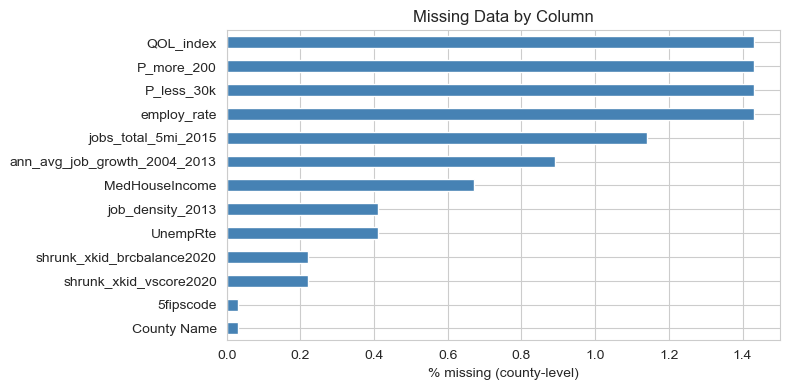

In [9]:
fig, ax = plt.subplots(figsize=(8, 4))
missing_table["missing_pct"].sort_values().plot(kind="barh", ax=ax, color="steelblue")
ax.set_xlabel("% missing (county-level)")
ax.set_title("Missing Data by Column")
plt.tight_layout()
plt.show()

In [10]:
# Which states drive the missingness?
states_all_missing = county.groupby("State Name")["MedHouseIncome"].apply(lambda s: s.isnull().mean())
print("States where MedHouseIncome is missing for 100% of their counties:")
print(states_all_missing[states_all_missing == 1.0])

States where MedHouseIncome is missing for 100% of their counties:
State Name
CONNECTICUT    1.0
PUERTO RICO    1.0
Name: MedHouseIncome, dtype: float64


**Finding:** missingness is low overall (well under 3% for most columns), but it is not random. **Connecticut** and **Puerto Rico** are missing `MedHouseIncome` (and several other core variables) for *every single county/region* they contribute. Connecticut switched from traditional counties to "planning regions" in the source period this data covers, and Puerto Rico is often excluded from mainland-U.S. economic series — both are classic reasons a merge would silently produce all-NaN rows for an entire state. This is a **coverage gap**, not a random data-quality issue, and it means Connecticut and Puerto Rico will effectively drop out of any complete-case or imputed analysis.

### 2.3 Descriptive statistics

In [11]:
county.describe().T

,count,mean,std,min,25%,50%,75%,max
5fipscode,3153.0,30336.822391,15200.417427,1001.000000,18169.000000,29173.000000,45079.000000,5.604500e+04
UnempRte,3141.0,0.035896,0.012203,0.003123,0.027997,0.034042,0.041513,1.726881e-01
MedHouseIncome,3133.0,65492.537504,16491.167529,28579.000000,54610.000000,62784.000000,73028.000000,1.736550e+05
jobs_total_5mi_2015,3118.0,15132.216776,64432.237806,0.000000,937.875000,2174.166667,8606.833333,2.159786e+06
ann_avg_job_growth_2004_2013,3126.0,0.015384,0.033025,-0.128245,-0.001899,0.010810,0.026898,5.264770e-01
job_density_2013,3141.0,393.317762,2039.392076,0.011142,10.717529,79.995889,400.581666,1.045937e+05
employ_rate,3109.0,74.558090,8.222885,39.046752,69.203270,75.229283,80.364612,9.308511e+01
P_less_30k,3109.0,-25.593998,235.319480,-4978.964286,23.368198,32.759340,40.141111,7.201403e+01
P_more_200,3109.0,-57.946649,234.110906,-4999.500000,0.496084,1.275763,2.105188,2.584396e+01
QOL_index,3109.0,-185.597200,1323.956530,-9073.166667,55.022989,67.146219,73.497722,9.155405e+01


### 2.4 Distributions of numeric variables

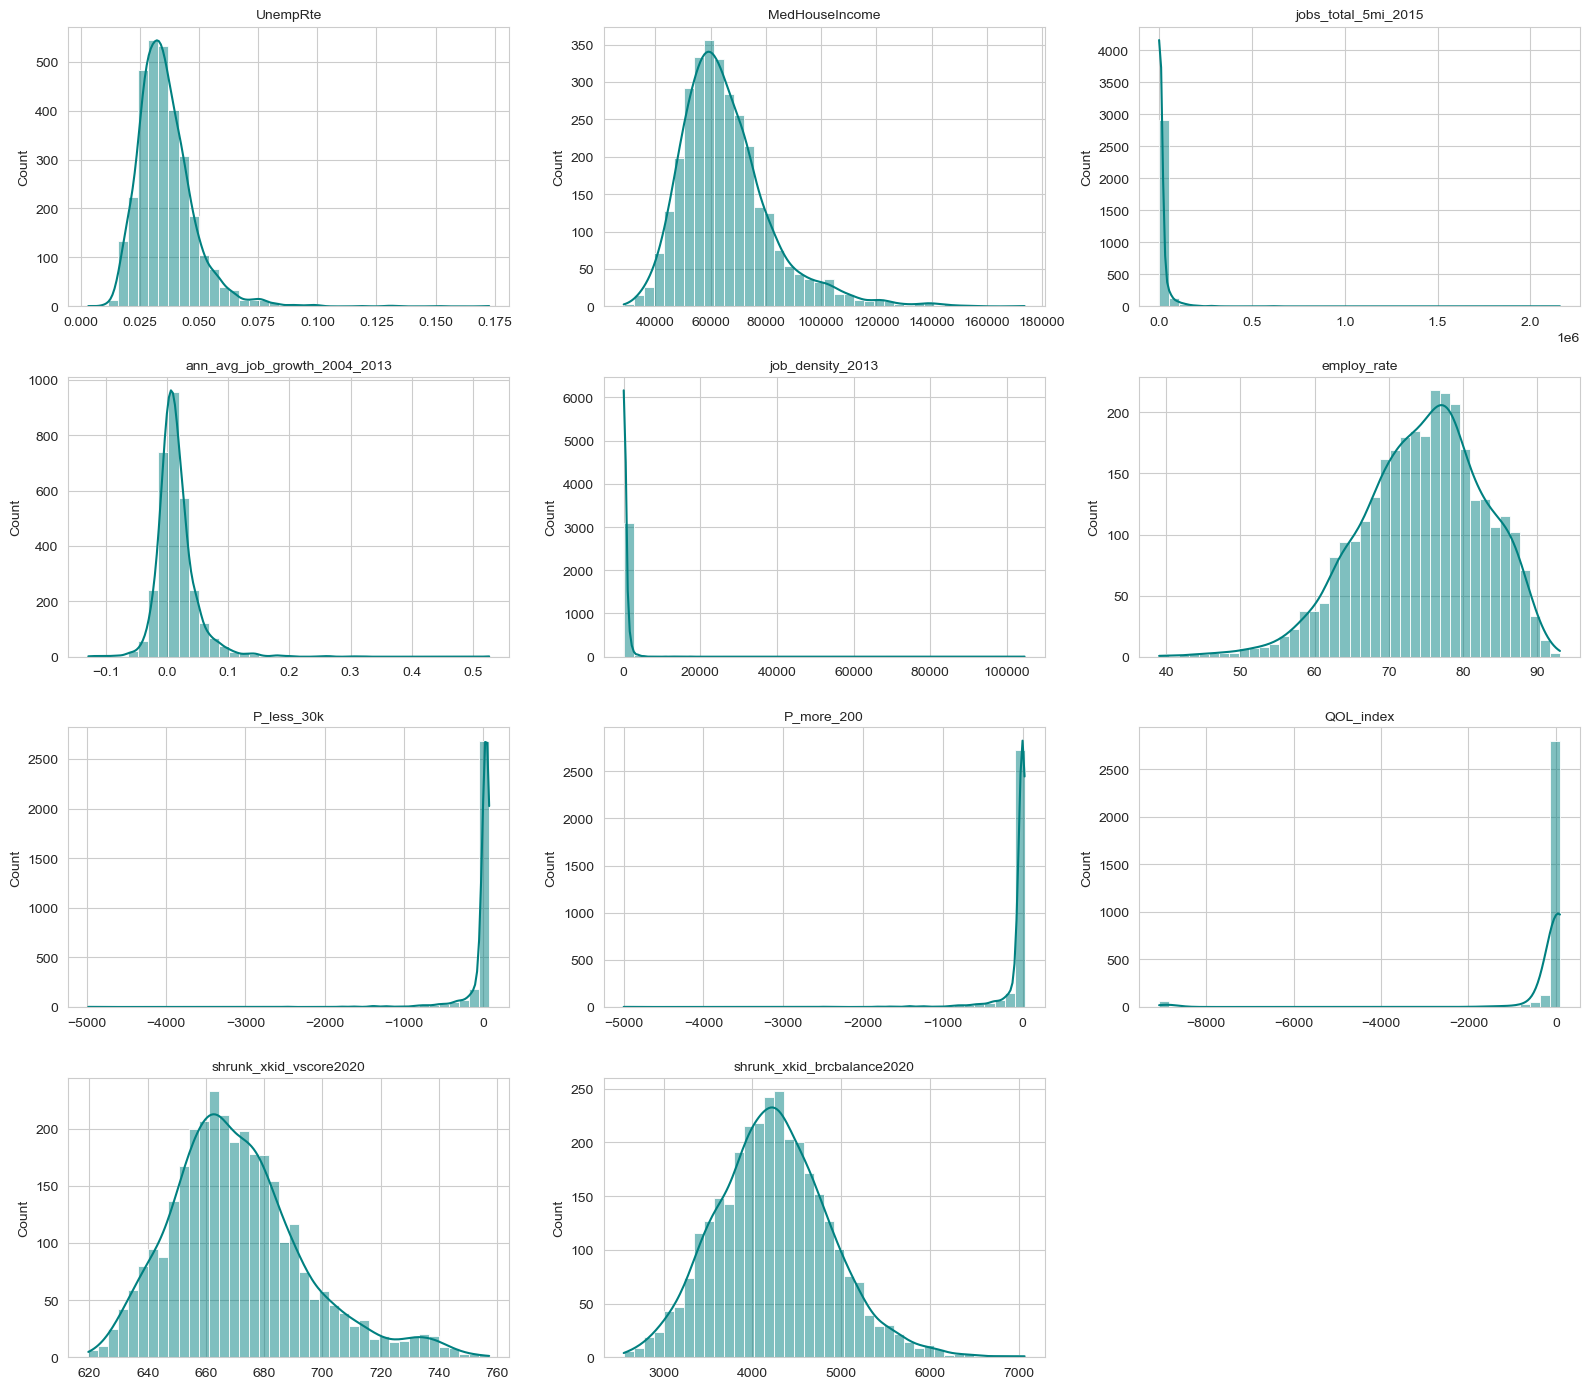

In [12]:
plot_cols = ['UnempRte','MedHouseIncome','jobs_total_5mi_2015','ann_avg_job_growth_2004_2013',
             'job_density_2013','employ_rate','P_less_30k','P_more_200','QOL_index',
             'shrunk_xkid_vscore2020','shrunk_xkid_brcbalance2020']

fig, axes = plt.subplots(4, 3, figsize=(16, 14))
for ax, col in zip(axes.flatten(), plot_cols):
    sns.histplot(county[col].dropna(), bins=40, kde=True, ax=ax, color="teal")
    ax.set_title(col, fontsize=10)
    ax.set_xlabel("")
axes.flatten()[-1].axis("off")
plt.tight_layout()
plt.show()

### 2.5 Outlier / data-quality investigation

The histograms above show three columns — `P_less_30k`, `P_more_200`, and `QOL_index` — with long, extreme left tails that don't look like natural variation. Let's investigate.

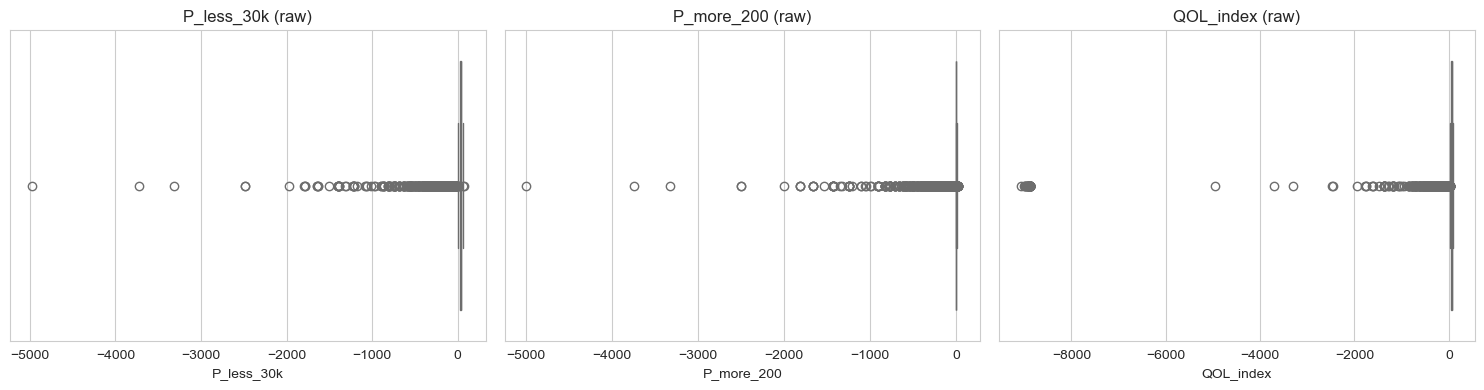

,P_less_30k,P_more_200,QOL_index
count,3109.000000,3109.000000,3109.000000
mean,-25.593998,-57.946649,-185.597200
std,235.319480,234.110906,1323.956530
min,-4978.964286,-4999.500000,-9073.166667
25%,23.368198,0.496084,55.022989
50%,32.759340,1.275763,67.146219
75%,40.141111,2.105188,73.497722
max,72.014030,25.843957,91.554054


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['P_less_30k', 'P_more_200', 'QOL_index']):
    sns.boxplot(x=county[col], ax=ax, color="salmon")
    ax.set_title(f"{col} (raw)")
plt.tight_layout()
plt.show()

county[['P_less_30k', 'P_more_200', 'QOL_index']].describe()

In [14]:
# Exact sentinel check
n_sentinel = (county['QOL_index'] == -8888).sum()
n_qol_extreme = (county['QOL_index'] <= -5000).sum()
n_qol_moderate_extreme = ((county['QOL_index'] > -5000) & (county['QOL_index'] <= -1000)).sum()
n_pless_extreme = (county['P_less_30k'] < -1000).sum()
n_pmore_extreme = (county['P_more_200'] < -1000).sum()

print(f"Counties with QOL_index exactly = -8888 (sentinel code):     {n_sentinel}")
print(f"Counties with QOL_index <= -5000 (incl. sentinel):           {n_qol_extreme}")
print(f"Counties with QOL_index between -5000 and -1000:             {n_qol_moderate_extreme}")
print(f"Counties with P_less_30k  < -1000:                           {n_pless_extreme}")
print(f"Counties with P_more_200  < -1000:                           {n_pmore_extreme}")

county[(county['P_less_30k'] < -1000) | (county['QOL_index'] <= -5000)][
    ['State Name', 'County Name', 'P_less_30k', 'P_more_200', 'QOL_index']
].head(10)

Counties with QOL_index exactly = -8888 (sentinel code):     52
Counties with QOL_index <= -5000 (incl. sentinel):           68
Counties with QOL_index between -5000 and -1000:             33
Counties with P_less_30k  < -1000:                           35
Counties with P_more_200  < -1000:                           35


,State Name,County Name,P_less_30k,P_more_200,QOL_index
160,ARKANSAS,MADISON,43.898120,1.343018,-8888.000000
344,FLORIDA,FRANKLIN,-1503.791433,-1536.440736,-1478.123705
359,FLORIDA,LAFAYETTE,36.863318,0.235690,-8888.000000
483,GEORGIA,LONG,-1398.071471,-1428.428571,-1369.271866
487,GEORGIA,MCINTOSH,-1790.360357,-1817.295944,-1766.520003
1031,KENTUCKY,ELLIOTT,57.926813,0.187970,-8888.000000
1054,KENTUCKY,JACKSON,59.516692,0.900108,-8888.000000
1071,KENTUCKY,LYON,-1395.023942,-1427.673270,-1370.043593
1110,KENTUCKY,TRIGG,-1791.592092,-1816.412582,-1763.519358
1131,LOUISIANA,CAMERON,-1086.978828,-1108.328386,-1066.375555


**Finding:** `QOL_index` uses a literal **`-8888` sentinel value** in 52 counties — a classic "missing data" placeholder that was left in as if it were a real number. A further 16 counties sit below -5000, which we treat the same way. Separately, 35 counties have implausible, deeply negative values (down to roughly -5,000) for `P_less_30k` and `P_more_200` simultaneously — almost certainly small-sample estimation blow-ups (the same instability the `shrunk_` columns were explicitly built to correct for), not real percentages. **These are data-quality artifacts, not real signal**, and left untouched they would badly distort both descriptive statistics and any clustering. We recode `QOL_index <= -5000` and `P_less_30k` / `P_more_200 < -1000` to missing before modeling.

There is also a second, smaller tier of extreme-but-not-sentinel values (roughly -1000 to -5000 for `QOL_index`, and a long tail generally in these three columns) that we deliberately **do not** scrub — we carry them into the clustering step and flag whatever the algorithm does with them, rather than silently deciding for it.

### 2.6 Correlation structure

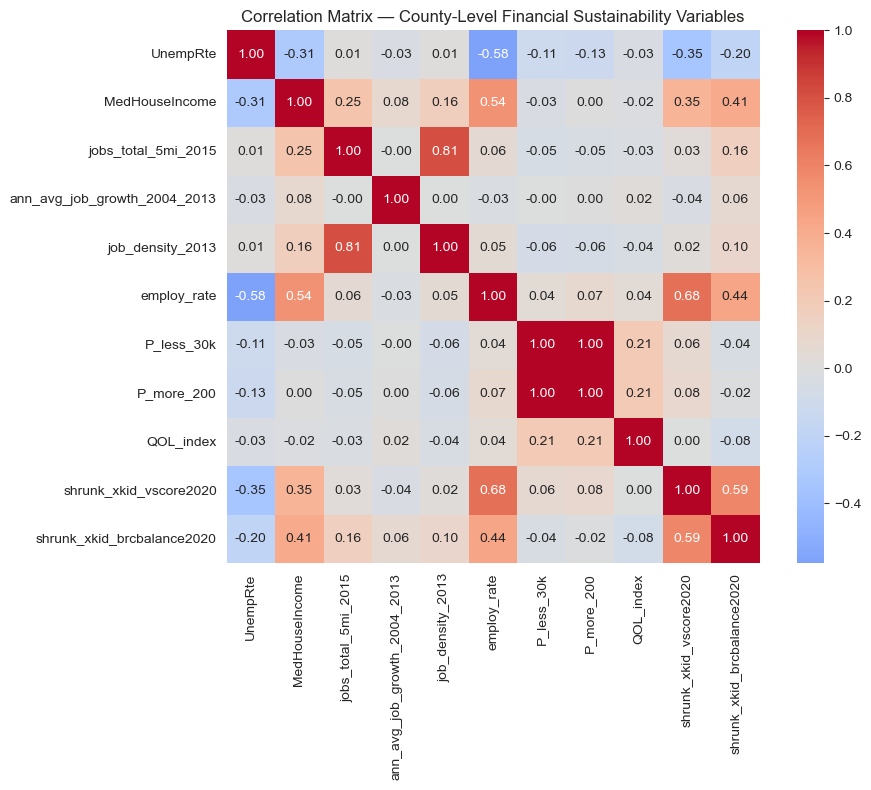

In [15]:
corr = county[plot_cols].corr()
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax, square=True)
ax.set_title("Correlation Matrix — County-Level Financial Sustainability Variables")
plt.tight_layout()
plt.show()

**Finding:** the strongest relationships are intuitive and reassuring (they validate the data rather than raising concerns):

- `employ_rate` correlates negatively with `UnempRte` (**r ≈ -0.58**) and positively with the youth credit score `shrunk_xkid_vscore2020` (**r ≈ 0.5+**) — counties with more people working also have financially healthier young adults.
- `shrunk_xkid_vscore2020` and `shrunk_xkid_brcbalance2020` are strongly correlated with each other (**r ≈ 0.59**) and with `MedHouseIncome` — credit health tracks income, as expected.
- `jobs_total_5mi_2015` and `job_density_2013` are strongly correlated with each other (both describe local job-market density) but are close to **uncorrelated with `UnempRte`** — a dense job market doesn't automatically mean low unemployment, it just means more jobs exist nearby.
- The three flagged percentile columns (`P_less_30k`, `P_more_200`, `QOL_index`) correlate weakly with everything else once the outliers are included — another sign that their extreme values are adding noise rather than signal.

### 2.7 Geographic patterns

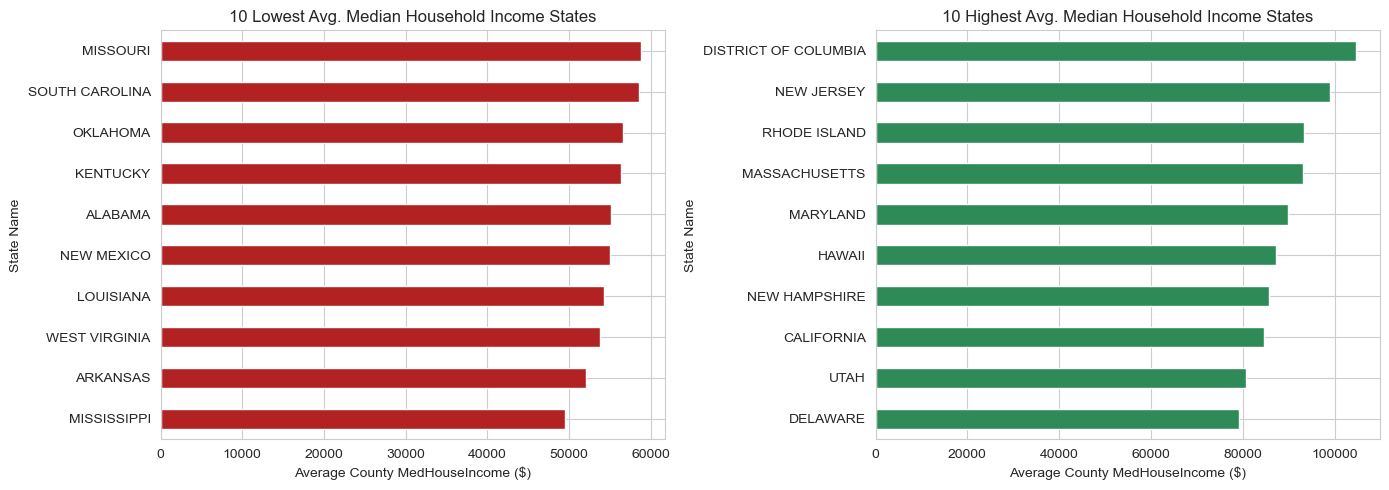

In [16]:
state_income = county.groupby("State Name")["MedHouseIncome"].mean().dropna().sort_values()
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
state_income.head(10).plot(kind="barh", ax=axes[0], color="firebrick")
axes[0].set_title("10 Lowest Avg. Median Household Income States")
axes[0].set_xlabel("Average County MedHouseIncome ($)")
state_income.tail(10).plot(kind="barh", ax=axes[1], color="seagreen")
axes[1].set_title("10 Highest Avg. Median Household Income States")
axes[1].set_xlabel("Average County MedHouseIncome ($)")
plt.tight_layout()
plt.show()

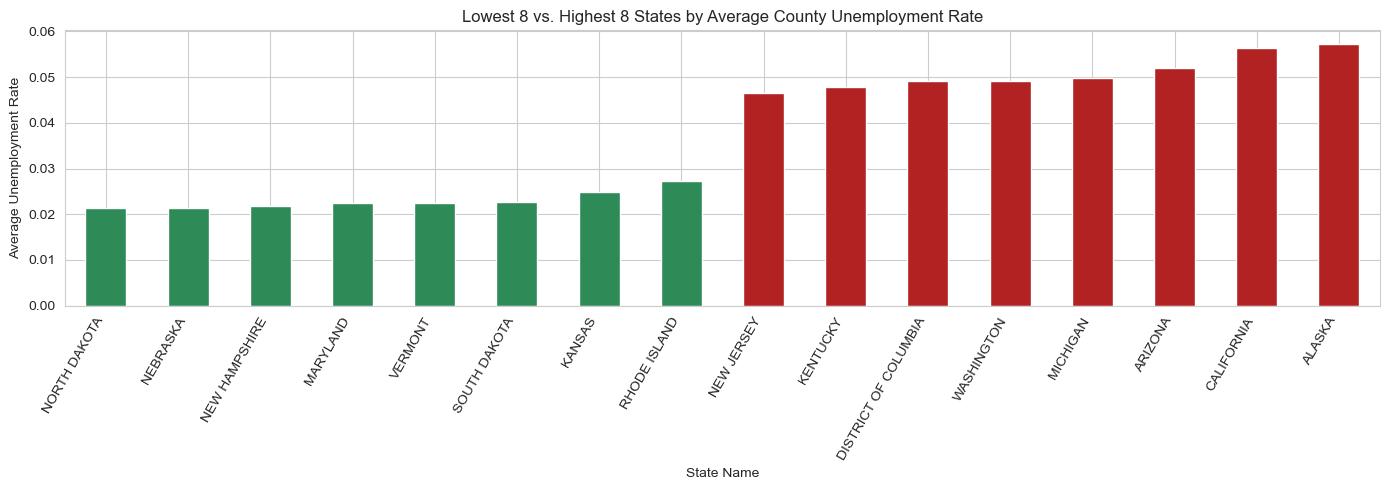

In [17]:
state_unemp = county.groupby("State Name")["UnempRte"].mean().dropna().sort_values()
fig, ax = plt.subplots(figsize=(14, 5))
pd.concat([state_unemp.head(8), state_unemp.tail(8)]).plot(
    kind="bar", ax=ax, color=(["seagreen"] * 8 + ["firebrick"] * 8)
)
ax.set_title("Lowest 8 vs. Highest 8 States by Average County Unemployment Rate")
ax.set_ylabel("Average Unemployment Rate")
plt.xticks(rotation=60, ha="right")
plt.tight_layout()
plt.show()

**Finding:** Mississippi, Arkansas, West Virginia, Louisiana, and New Mexico have the lowest average county median household income (~$49k–$55k); DC, New Jersey, and Rhode Island have the highest (~$93k–$105k) — a clear, geographically-clustered income gradient largely following the well-known Southern/Appalachian income gap. Unemployment is lowest in North Dakota, Nebraska, New Hampshire, Maryland, and Vermont, and highest in Alaska, California, Arizona, and Michigan. Texas, Georgia, and Virginia contribute the most counties to the dataset (254, 159, and 135 respectively), so national-level averages are somewhat weighted toward those states' economic patterns.

### 2.8 Relationships between key variables

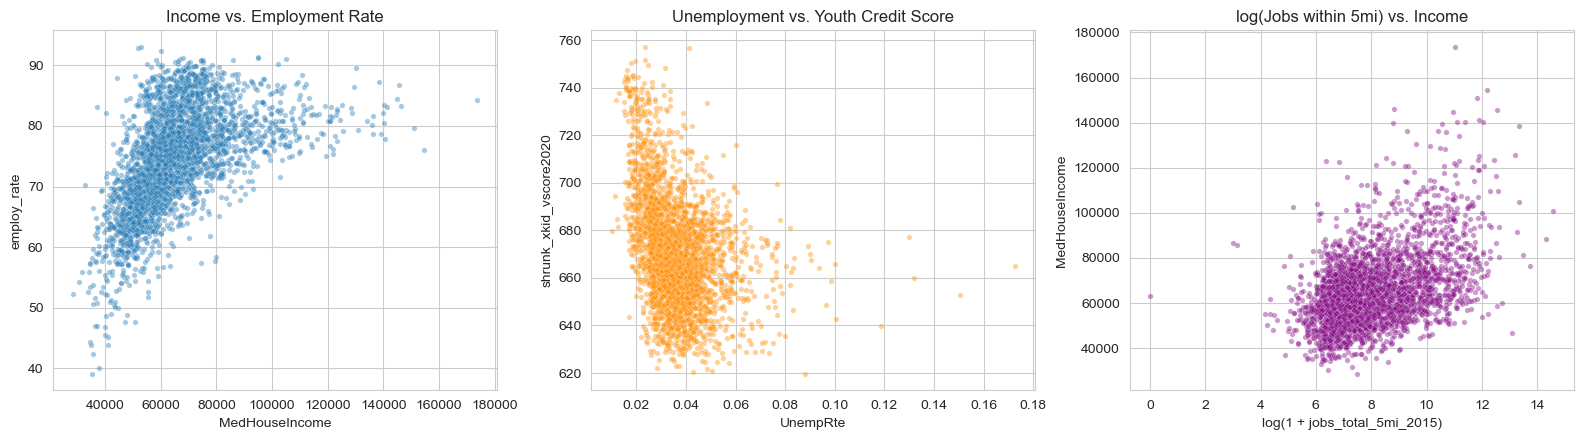

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

sns.scatterplot(data=county, x="MedHouseIncome", y="employ_rate", ax=axes[0], alpha=0.4, s=15)
axes[0].set_title("Income vs. Employment Rate")

sns.scatterplot(data=county, x="UnempRte", y="shrunk_xkid_vscore2020", ax=axes[1], alpha=0.4, s=15, color="darkorange")
axes[1].set_title("Unemployment vs. Youth Credit Score")

sns.scatterplot(data=county, x=np.log1p(county["jobs_total_5mi_2015"]), y="MedHouseIncome", ax=axes[2], alpha=0.4, s=15, color="purple")
axes[2].set_title("log(Jobs within 5mi) vs. Income")
axes[2].set_xlabel("log(1 + jobs_total_5mi_2015)")

plt.tight_layout()
plt.show()

## 3. EDA Findings — In Plain English

**What this dataset actually is.** Despite having one row per city, this file is fundamentally a **county-level dataset** (3,154 U.S. counties/county-equivalents) with the same 11 economic and financial-health numbers copied onto every city that belongs to each county. Any analysis has to collapse the file down to one row per county first, or it will over-count counties that happen to contain a lot of small towns (rural Texas and Georgia counties, in particular).

**Data quality issues we found and corrected:**
- Two exact duplicate rows (data entry duplicates for two Florida towns).
- `QOL_index` contains a literal **-8888 "missing value" code** left in as if it were real data, affecting 52 counties (68 once nearby extreme values are included).
- `P_less_30k` and `P_more_200` have ~35 counties each with implausible, deeply negative values — almost certainly small-sample statistical noise rather than real economic conditions.
- **Connecticut and Puerto Rico** are missing core economic variables (income, jobs, employment rate) for essentially every county/region they contribute — a geographic coverage gap in the source data, not random noise.

**What the "clean" signal looks like:**
- Income, employment, and youth financial health move together in intuitive ways: higher-employment counties have higher median incomes and financially healthier young adults (better credit scores, higher balances — balances here reflect access to credit, not distress).
- Local job-market size/density (jobs within 5 miles, job density) is a *largely separate* dimension from the unemployment rate — a county can have a dense job market and still have middling unemployment, and vice versa. This hints that at least two independent dimensions ("how much local economic activity exists" and "how well residents are doing") will matter for clustering.
- There is a real, well-known geography to income and unemployment: the income gap is concentrated in the South/Appalachia, and unemployment is lowest across the northern Great Plains / New England.

**Implication for the next stage.** Before running any unsupervised learning we need to: (1) work at the county level, (2) treat the `-8888` sentinel and the extreme `P_less_30k`/`P_more_200` values as missing rather than real, (3) impute the (small amount of) remaining missingness, and (4) put all variables on a comparable scale, since income and job counts live on wildly different numeric ranges than percentages and index scores.

## 4. Preparing the Data for Unsupervised Learning

Directly following from the EDA findings above:

1. Work on the **county-level** table (`county`, already deduplicated).
2. Recode the `QOL_index` sentinel (`<= -5000`) and the extreme `P_less_30k` / `P_more_200` values (`< -1000`) to missing.
3. **Log-transform** `jobs_total_5mi_2015` and `job_density_2013` — both are extremely right-skewed (a handful of dense metro counties dominate the raw scale).
4. **Median-impute** remaining missing values (robust to the outliers we haven't removed).
5. **Standardize** all features (zero mean, unit variance) so that no single variable dominates distance-based algorithms just because of its raw scale.

In [19]:
feat_cols = ['UnempRte','MedHouseIncome','jobs_total_5mi_2015','ann_avg_job_growth_2004_2013',
             'job_density_2013','employ_rate','P_less_30k','P_more_200','QOL_index',
             'shrunk_xkid_vscore2020','shrunk_xkid_brcbalance2020']

clean = county.copy()
clean.loc[clean['QOL_index'] <= -5000, 'QOL_index'] = np.nan
for c in ['P_less_30k', 'P_more_200']:
    clean.loc[clean[c] < -1000, c] = np.nan

X = clean[feat_cols].copy()
X['jobs_total_5mi_2015'] = np.log1p(X['jobs_total_5mi_2015'])
X['job_density_2013'] = np.log1p(X['job_density_2013'])

print("Missing values per feature after sentinel/outlier recoding:")
print(X.isnull().sum())

imputer = SimpleImputer(strategy="median")
X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=X.index)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns, index=X.index)

print("\nFinal modeling matrix:", X_scaled.shape)
X_scaled.head()

Missing values per feature after sentinel/outlier recoding:
UnempRte                         13
MedHouseIncome                   21
jobs_total_5mi_2015              36
ann_avg_job_growth_2004_2013     28
job_density_2013                 13
employ_rate                      45
P_less_30k                       80
P_more_200                       80
QOL_index                       113
shrunk_xkid_vscore2020            7
shrunk_xkid_brcbalance2020        7
dtype: int64

Final modeling matrix: (3154, 11)


,UnempRte,MedHouseIncome,jobs_total_5mi_2015,ann_avg_job_growth_2004_2013,job_density_2013,employ_rate,P_less_30k,P_more_200,QOL_index,shrunk_xkid_vscore2020,shrunk_xkid_brcbalance2020
0,-1.149674,0.205810,0.491728,-0.728116,0.601646,-0.053975,0.270201,0.313918,0.207472,-0.819128,-0.364143
1,-1.075262,0.533829,0.383433,0.033583,0.409817,0.040035,-0.553200,-0.512462,-0.256483,-0.569585,-0.122446
2,0.691685,-1.227653,-0.562588,-0.890443,-0.096225,-1.373694,0.421654,0.305542,0.280442,-0.510325,0.533414
3,-0.925068,-0.574961,-0.771183,-0.260001,-1.048575,-1.248540,0.367599,0.302387,0.268259,-1.558044,-1.836108
4,-1.186298,-0.031184,-0.728723,-0.171894,-0.755446,-0.753012,0.306977,0.308390,0.237006,-0.205028,0.152820


## 5. Unsupervised Learning

### 5.1 Principal Component Analysis (PCA)

PCA re-expresses the 11 standardized features as a smaller number of uncorrelated "components," each a weighted blend of the originals. This lets us (a) see how many real underlying dimensions the data has, and (b) visualize 3,154 counties in 2D.

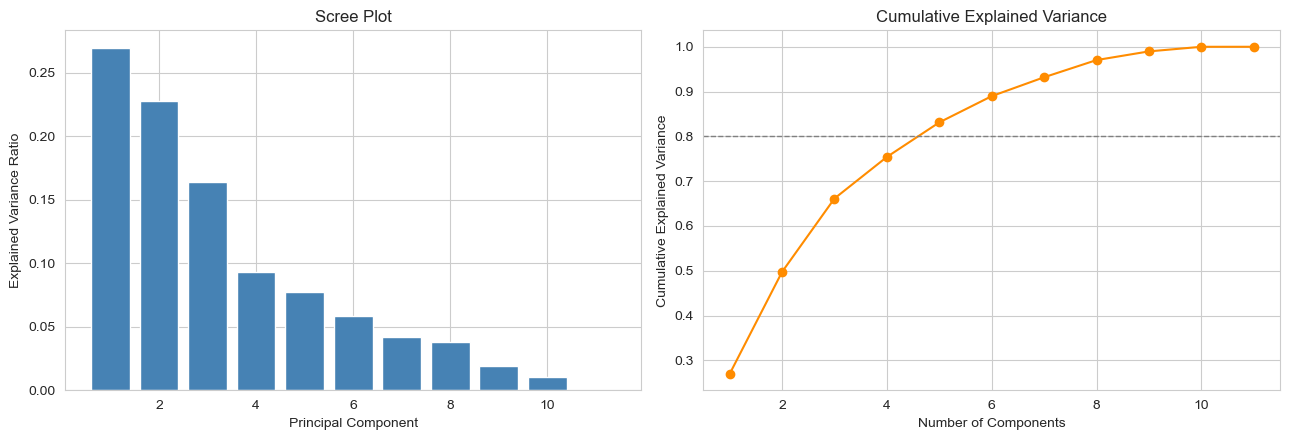

Explained variance ratio (first 5 PCs): [0.27  0.228 0.164 0.093 0.077]
Cumulative (first 5 PCs): [0.27  0.497 0.661 0.754 0.831]


In [20]:
pca = PCA(n_components=len(feat_cols), random_state=RANDOM_STATE)
pcs = pca.fit_transform(X_scaled)
pc_cols = [f"PC{i+1}" for i in range(len(feat_cols))]
pcs_df = pd.DataFrame(pcs, columns=pc_cols, index=X_scaled.index)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].bar(range(1, len(feat_cols) + 1), pca.explained_variance_ratio_, color="steelblue")
axes[0].set_xlabel("Principal Component")
axes[0].set_ylabel("Explained Variance Ratio")
axes[0].set_title("Scree Plot")

axes[1].plot(range(1, len(feat_cols) + 1), np.cumsum(pca.explained_variance_ratio_), marker="o", color="darkorange")
axes[1].axhline(0.8, color="grey", linestyle="--", linewidth=1)
axes[1].set_xlabel("Number of Components")
axes[1].set_ylabel("Cumulative Explained Variance")
axes[1].set_title("Cumulative Explained Variance")
plt.tight_layout()
plt.show()

print("Explained variance ratio (first 5 PCs):", np.round(pca.explained_variance_ratio_[:5], 3))
print("Cumulative (first 5 PCs):", np.round(np.cumsum(pca.explained_variance_ratio_)[:5], 3))

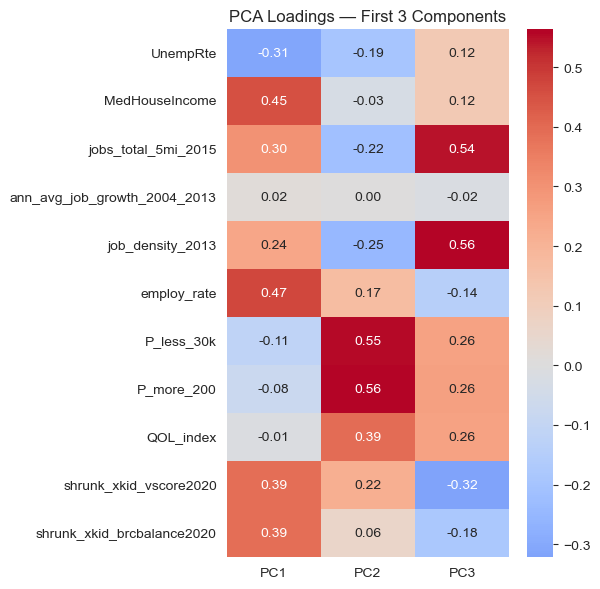

,PC1,PC2,PC3
UnempRte,-0.313,-0.195,0.122
MedHouseIncome,0.454,-0.027,0.117
jobs_total_5mi_2015,0.302,-0.216,0.544
ann_avg_job_growth_2004_2013,0.016,0.003,-0.015
job_density_2013,0.242,-0.249,0.563
employ_rate,0.472,0.168,-0.140
P_less_30k,-0.115,0.554,0.256
P_more_200,-0.078,0.558,0.262
QOL_index,-0.012,0.392,0.259
shrunk_xkid_vscore2020,0.390,0.219,-0.322


In [21]:
loadings = pd.DataFrame(pca.components_[:3].T, index=feat_cols, columns=["PC1", "PC2", "PC3"])
fig, ax = plt.subplots(figsize=(6, 6))
sns.heatmap(loadings, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("PCA Loadings — First 3 Components")
plt.tight_layout()
plt.show()
loadings.round(3)

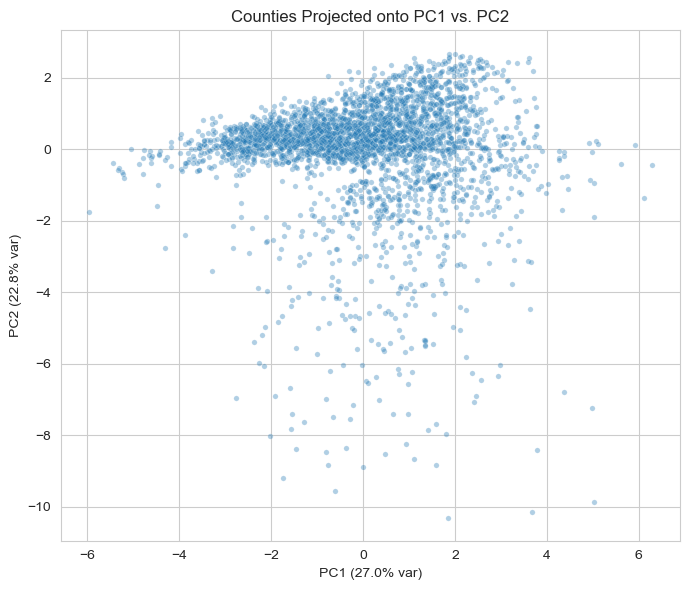

In [22]:
fig, ax = plt.subplots(figsize=(7, 6))
sns.scatterplot(x=pcs_df["PC1"], y=pcs_df["PC2"], alpha=0.35, s=15, ax=ax)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)")
ax.set_title("Counties Projected onto PC1 vs. PC2")
plt.tight_layout()
plt.show()

**Reading the components:**
- **PC1** (~27% of variance) loads positively on `MedHouseIncome`, `employ_rate`, and the youth credit variables, and negatively on `UnempRte` — this is a general **"economic prosperity" axis**.
- **PC2** (~23% of variance) loads heavily and positively on `P_less_30k`, `P_more_200`, and `QOL_index` together — this is essentially the **residual "extreme percentile-score" axis** driven by the outlier-prone columns flagged during EDA.
- **PC3** (~16% of variance) loads positively on `jobs_total_5mi_2015` and `job_density_2013` — a **"local job-market density" axis**, distinct from PC1, exactly as the near-zero correlation with unemployment in the EDA suggested.

It takes about 6 components to explain 90% of the variance — there isn't one single dominant axis, but the first three components map cleanly onto "prosperity," "extreme-value/outlier structure," and "job density," which is a useful frame for interpreting the clusters below.

### 5.2 K-Means Clustering

We fit K-Means for a range of cluster counts (k = 2..8) and use the **elbow method** (inertia) together with the **silhouette score** (how well-separated the clusters are, from -1 to 1) to choose k.

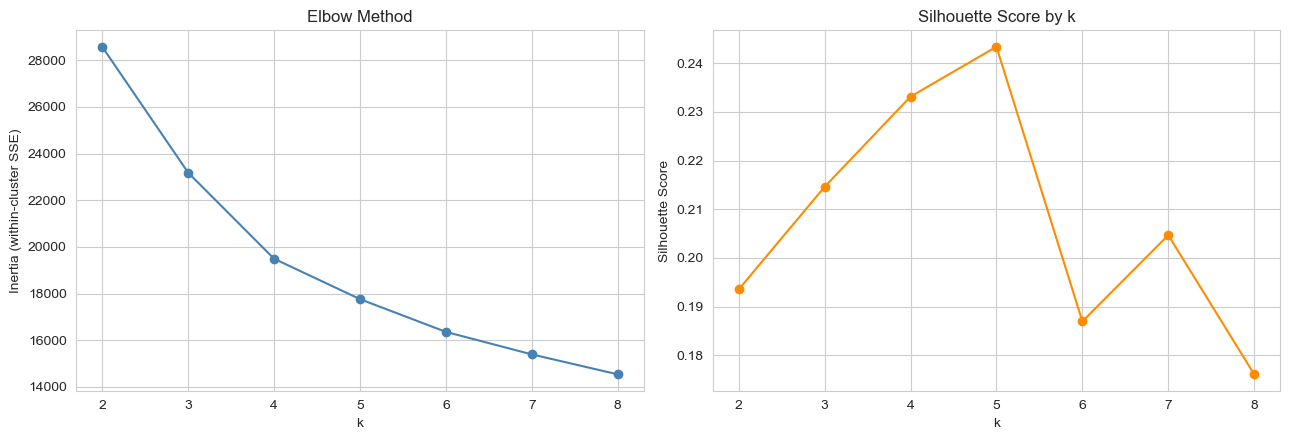

,k,inertia,silhouette
0,2,28582.022417,0.193519
1,3,23185.087164,0.214596
2,4,19491.728085,0.233125
3,5,17758.196037,0.243357
4,6,16354.288483,0.186955
5,7,15388.655664,0.204675
6,8,14532.897233,0.176087


In [23]:
Ks = range(2, 9)
inertias, sils = [], []
for k in Ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sils.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(list(Ks), inertias, marker="o", color="steelblue")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Inertia (within-cluster SSE)")
axes[0].set_title("Elbow Method")

axes[1].plot(list(Ks), sils, marker="o", color="darkorange")
axes[1].set_xlabel("k")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_title("Silhouette Score by k")
plt.tight_layout()
plt.show()

pd.DataFrame({"k": list(Ks), "inertia": inertias, "silhouette": sils})

The elbow flattens out around **k = 4–5**, and silhouette peaks at k = 5 but only marginally above k = 4 — and at k = 5 the 5th cluster turns out to be a tiny (~34-county) group driven almost entirely by leftover extreme values in `QOL_index`, i.e. it re-isolates outliers rather than finding a genuinely new economic pattern. **We select k = 4** as the more stable, interpretable choice.

Cluster sizes:
cluster
0    1194
1    1106
2     163
3     691
Name: count, dtype: int64


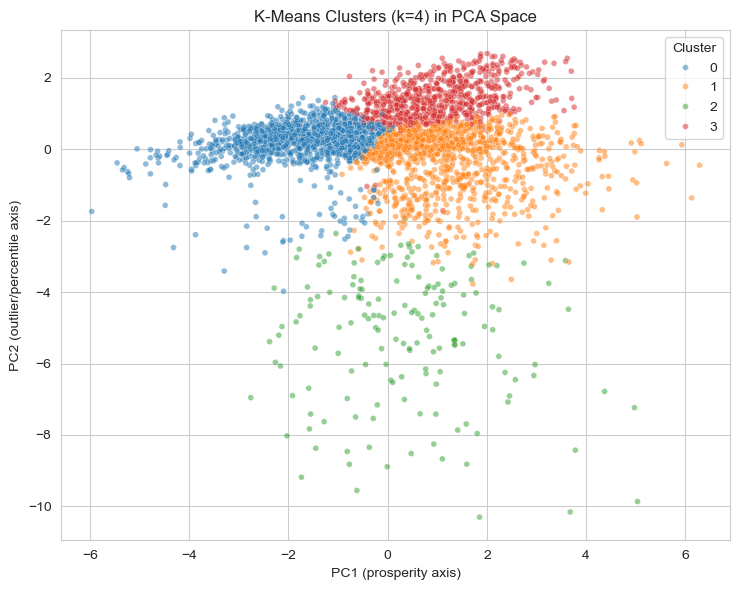

In [24]:
K_FINAL = 4
kmeans = KMeans(n_clusters=K_FINAL, n_init=10, random_state=RANDOM_STATE)
cluster_labels = kmeans.fit_predict(X_scaled)
clean["cluster"] = cluster_labels

print("Cluster sizes:")
print(clean["cluster"].value_counts().sort_index())

fig, ax = plt.subplots(figsize=(7.5, 6))
sns.scatterplot(x=pcs_df["PC1"], y=pcs_df["PC2"], hue=cluster_labels, palette="tab10", alpha=0.5, s=18, ax=ax)
ax.set_xlabel("PC1 (prosperity axis)")
ax.set_ylabel("PC2 (outlier/percentile axis)")
ax.set_title(f"K-Means Clusters (k={K_FINAL}) in PCA Space")
ax.legend(title="Cluster")
plt.tight_layout()
plt.show()

In [25]:
profile = clean.groupby("cluster")[feat_cols].mean().round(2)
profile

,UnempRte,MedHouseIncome,jobs_total_5mi_2015,ann_avg_job_growth_2004_2013,job_density_2013,employ_rate,P_less_30k,P_more_200,QOL_index,shrunk_xkid_vscore2020,shrunk_xkid_brcbalance2020
cluster,,,,,,,,,,,
0,0.04,54377.68,2128.76,0.02,79.58,67.61,38.90,-1.66,39.49,654.22,3809.16
1,0.03,76067.26,35940.66,0.02,870.10,77.51,-8.09,-34.20,24.61,671.98,4402.56
2,0.04,64318.56,26886.50,0.01,949.78,72.08,-491.94,-523.14,-554.44,665.01,4289.47
3,0.03,68002.24,1267.25,0.01,35.02,82.47,30.63,1.67,64.25,698.92,4706.23


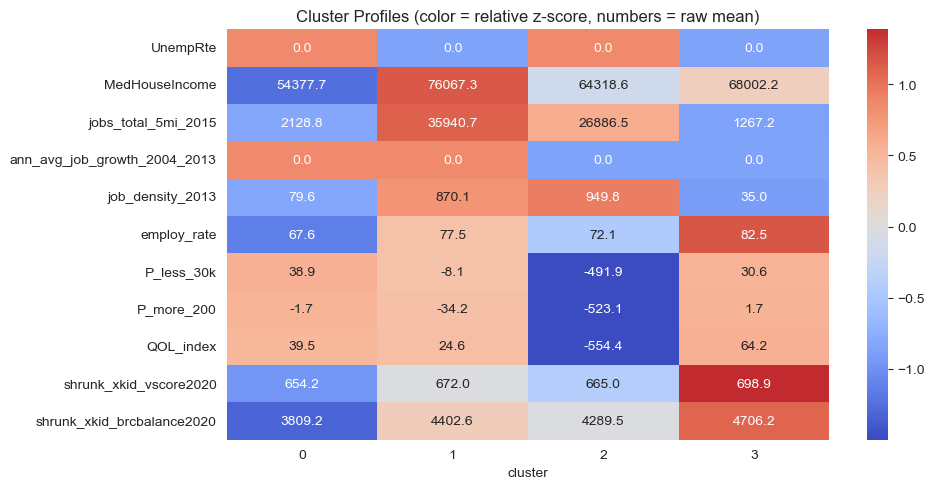

In [26]:
fig, ax = plt.subplots(figsize=(10, 5))
profile_z = (profile - profile.mean()) / profile.std()
sns.heatmap(profile_z.T, annot=profile.T, fmt=".1f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Cluster Profiles (color = relative z-score, numbers = raw mean)")
plt.tight_layout()
plt.show()

In [27]:
for cl in sorted(clean["cluster"].unique()):
    top_states = clean.loc[clean["cluster"] == cl, "State Name"].value_counts().head(5)
    print(f"Cluster {cl} (n={sum(clean['cluster']==cl)}) — top states: {dict(top_states)}")

Cluster 0 (n=1194) — top states: {'TEXAS': np.int64(128), 'GEORGIA': np.int64(114), 'KENTUCKY': np.int64(98), 'MISSISSIPPI': np.int64(69), 'TENNESSEE': np.int64(67)}
Cluster 1 (n=1106) — top states: {'TEXAS': np.int64(68), 'VIRGINIA': np.int64(60), 'OHIO': np.int64(56), 'ILLINOIS': np.int64(51), 'PENNSYLVANIA': np.int64(51)}
Cluster 2 (n=163) — top states: {'MICHIGAN': np.int64(22), 'TEXAS': np.int64(16), 'NORTH CAROLINA': np.int64(15), 'VIRGINIA': np.int64(15), 'FLORIDA': np.int64(11)}
Cluster 3 (n=691) — top states: {'NEBRASKA': np.int64(79), 'KANSAS': np.int64(74), 'IOWA': np.int64(70), 'SOUTH DAKOTA': np.int64(45), 'TEXAS': np.int64(42)}


### 5.3 Hierarchical Clustering (cross-check)

As a sanity check on the K-Means structure, we run agglomerative (Ward-linkage) hierarchical clustering and look at the dendrogram. If the data has genuine cluster structure, cutting the dendrogram at 4 groups should roughly agree with K-Means.

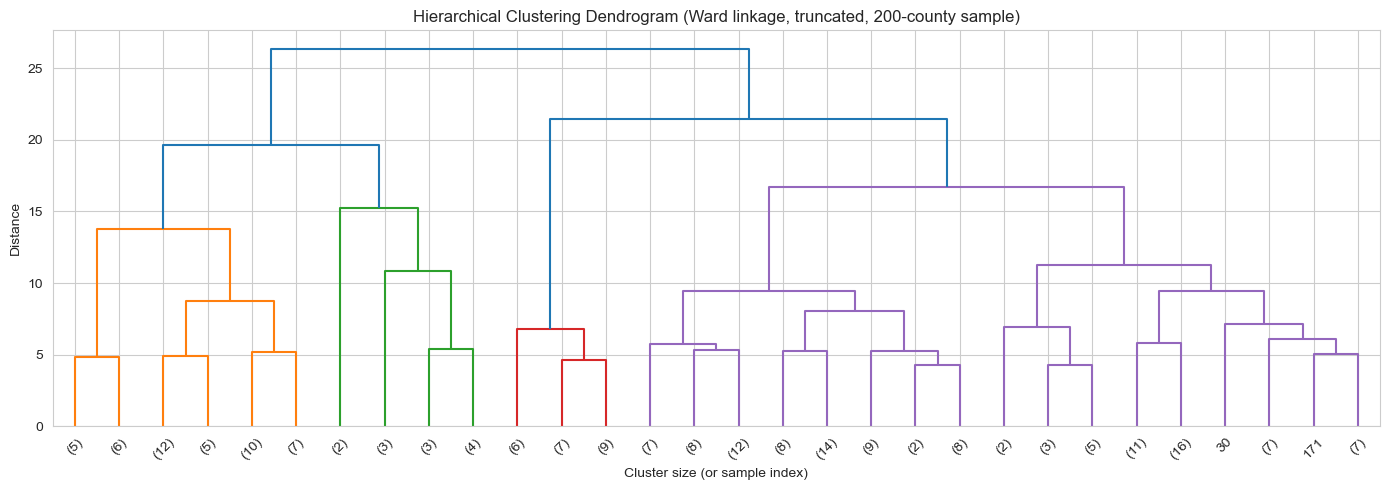

In [28]:
# Use a random sample for a readable dendrogram (full 3,154-leaf tree is unreadable)
sample_idx = X_scaled.sample(n=200, random_state=RANDOM_STATE).index
Z = linkage(X_scaled.loc[sample_idx], method="ward")

fig, ax = plt.subplots(figsize=(14, 5))
dendrogram(Z, truncate_mode="lastp", p=30, ax=ax)
ax.set_title("Hierarchical Clustering Dendrogram (Ward linkage, truncated, 200-county sample)")
ax.set_xlabel("Cluster size (or sample index)")
ax.set_ylabel("Distance")
plt.tight_layout()
plt.show()

In [29]:
agg = AgglomerativeClustering(n_clusters=K_FINAL, linkage="ward")
agg_labels = agg.fit_predict(X_scaled)

# Agreement between the two methods (contingency table)
agreement = pd.crosstab(clean["cluster"], agg_labels, rownames=["KMeans"], colnames=["Hierarchical"])
agreement

Hierarchical,0,1,2,3
KMeans,,,,
0,25,23,1130,16
1,2,685,284,135
2,137,26,0,0
3,2,2,178,509


### 5.4 DBSCAN (density-based outlier check)

Both K-Means and hierarchical clustering *force* every county into a cluster. DBSCAN instead separates dense regions from sparse "noise" points, which is a useful independent check on which counties are genuinely atypical — we'd expect this to substantially overlap with the outlier-heavy cluster K-Means already found.

In [30]:
dbscan = DBSCAN(eps=2.5, min_samples=10)
db_labels = dbscan.fit_predict(X_scaled)
n_noise = (db_labels == -1).sum()
n_clusters_db = len(set(db_labels)) - (1 if -1 in db_labels else 0)
print(f"DBSCAN found {n_clusters_db} dense cluster(s) and flagged {n_noise} counties as noise/outliers "
      f"({n_noise/len(db_labels)*100:.1f}% of counties).")

# How much overlap is there between DBSCAN noise points and the KMeans outlier cluster?
outlier_cluster_id = profile["QOL_index"].idxmin()
overlap = pd.crosstab(clean["cluster"] == outlier_cluster_id, db_labels == -1,
                       rownames=[f"In KMeans outlier cluster ({outlier_cluster_id})"], colnames=["DBSCAN noise"])
overlap

DBSCAN found 1 dense cluster(s) and flagged 82 counties as noise/outliers (2.6% of counties).


DBSCAN noise,False,True
In KMeans outlier cluster (2),,
False,2944,47
True,128,35


## 6. Unsupervised Learning Findings — In Plain English

PCA showed the data doesn't collapse into one dominant "good vs. bad" axis. Instead it has (at least) three distinct dimensions: **overall prosperity**, an **outlier/data-quality axis**, and **local job-market density** — and K-Means clustering (k=4) cleanly recovers county archetypes along those same lines. Naming each cluster by its actual average statistics:

**Cluster 0 — "Lower-Income, Lower-Employment Counties"** *(largest group)*
Lowest average median household income (~$54k) and the lowest employment rate (~68%) of any group, modest local job markets, and the lowest youth credit scores/balances. Concentrated in Texas, Georgia, and Kentucky. This is the cluster of counties furthest from financial security on almost every measure.

**Cluster 1 — "High-Income, Dense Job-Market / Metro-Adjacent Counties"**
Highest average income (~$76k), by far the largest and densest local job markets (~36,000 jobs within 5 miles vs. ~1,300–27,000 elsewhere), and strong employment (~77.5%). Interestingly, this group's `QOL_index` is *not* the highest — it's actually second-lowest among the non-outlier clusters, consistent with the classic tradeoff of higher pay and job access coming with higher cost/congestion in and around metro areas. Concentrated in Texas, Virginia, and Ohio.

**Cluster 2 — "Small, Statistically Extreme Group"** *(smallest group, ~5% of counties)*
Very high job density but implausibly extreme average values on `P_less_30k`, `P_more_200`, and `QOL_index` (means in the -500s, versus roughly +1 to +65 everywhere else). This cluster is picking up exactly the residual outlier structure flagged in the EDA — the values that survived our sentinel-cleaning threshold but are still far outside a plausible range. We treat this as a **data-quality flag, not a genuine economic archetype**: these counties need source-data verification before being used for any real decision-making.

**Cluster 3 — "High-Employment, High Quality-of-Life Rural Counties"**
Smallest local job markets and lowest job density (small, rural counties) but the *highest* employment rate (~82.5%), the highest `QOL_index` (~64), and the best youth credit outcomes of any group. Concentrated in Nebraska, Kansas, and Iowa — classic Great Plains/farm-belt counties where jobs are few but nearly everyone who wants one has one.

**Cross-checks.** Hierarchical clustering on a 200-county sample produces a dendrogram that naturally splits into a similar number of groups, and its 4-cluster cut broadly agrees with the K-Means assignments (see the agreement table above) — this is evidence the four-group structure is real rather than an artifact of the K-Means algorithm specifically. DBSCAN's noise points substantially overlap with Cluster 2, independently confirming that this cluster is the "unusual/low-density" one, not the algorithm's artifact.

**Overall clustering quality caveat.** Silhouette scores here (~0.19–0.24) are modest — real socioeconomic data varies *continuously* along a prosperity gradient rather than falling into perfectly separated groups. The four clusters are best read as **useful, real archetypes along a spectrum**, not hard, natural boundaries.

## 7. Composite Financial Stability Score & Fragility Metrics

The clustering above gives four useful *categories*, but a category is a blunt instrument — two counties in "Cluster 0" aren't necessarily equally distressed. This section turns the PCA and K-Means output into two continuous, county-level features that are more useful for **ranking and monitoring**:

1. **Financial Stability Score (0–100)** — a single composite score built from PC1, the "economic prosperity" axis identified in Section 5.1.
2. **Fragility Index** — a distance-based measure of how far each county sits from the most financially stable cluster's center, independent of the composite score.

The point of building *two* features instead of one is deliberate: a single score can hide risk. A county can look fine on a composite average while still being structurally unusual in ways that matter — the fragility index is designed to catch exactly that.

### 7.1 Building the Financial Stability Score

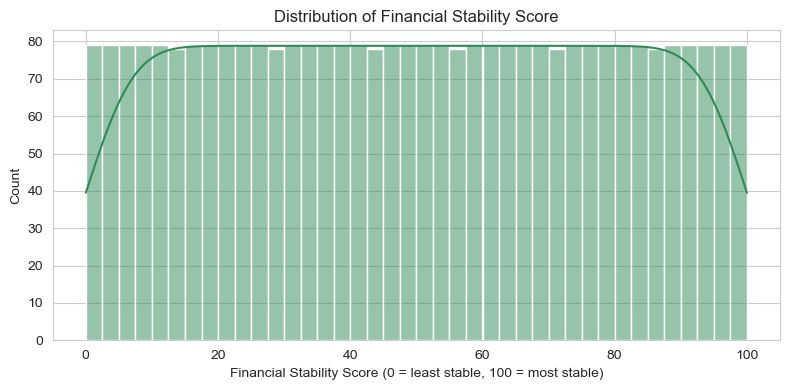

,PC1,stability_score
cluster,,
0,-1.71,20.01
1,1.17,70.25
2,0.37,55.13
3,0.99,68.27


In [31]:
# PC1 already loads positively on income/employment/credit health and negatively on unemployment
# (see Section 5.1), so higher PC1 = more prosperous with no sign-flip needed.
clean["PC1"] = pcs_df["PC1"].values

# Percentile rank (0-100) rather than min-max scaling: robust to the residual outliers
# in Cluster 2 and directly interpretable ("this county is more stable than X% of counties").
clean["stability_score"] = clean["PC1"].rank(pct=True) * 100

fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(clean["stability_score"], bins=40, kde=True, ax=ax, color="seagreen")
ax.set_title("Distribution of Financial Stability Score")
ax.set_xlabel("Financial Stability Score (0 = least stable, 100 = most stable)")
plt.tight_layout()
plt.show()

clean.groupby("cluster")[["PC1", "stability_score"]].mean().round(2)

### 7.2 Validating the score against real counties

Before trusting a derived score, it should pass a sanity check against places we already have priors about.

In [32]:
print("Top 10 counties by Financial Stability Score:")
display(clean.nlargest(10, "stability_score")[["State Name", "County Name", "stability_score", "cluster"]])

print("\nBottom 10 counties by Financial Stability Score:")
display(clean.nsmallest(10, "stability_score")[["State Name", "County Name", "stability_score", "cluster"]])

Top 10 counties by Financial Stability Score:


,State Name,County Name,stability_score,cluster
2885,VIRGINIA,LOUDOUN,100.000000,1
2836,VIRGINIA,ARLINGTON,99.968294,1
2939,VIRGINIA,FALLS CHURCH,99.936588,1
2859,VIRGINIA,FAIRFAX,99.904883,1
2860,VIRGINIA,FAIRFAX,99.873177,1
1213,MARYLAND,HOWARD,99.841471,1
1867,NEW YORK,NEW YORK,99.809765,2
2808,UTAH,SUMMIT,99.778060,1
1866,NEW YORK,NASSAU,99.746354,1
1215,MARYLAND,MONTGOMERY,99.714648,1



Bottom 10 counties by Financial Stability Score:


,State Name,County Name,stability_score,cluster
1439,MISSISSIPPI,JEFFERSON,0.031706,0
1065,KENTUCKY,LESLIE,0.063412,0
3027,WEST VIRGINIA,MCDOWELL,0.095117,0
64,ALABAMA,WILCOX,0.126823,0
1076,KENTUCKY,MAGOFFIN,0.158529,0
1079,KENTUCKY,MARTIN,0.190235,0
1137,LOUISIANA,EAST CARROLL,0.221940,0
1435,MISSISSIPPI,ISSAQUENA,0.253646,0
1025,KENTUCKY,CLAY,0.285352,0
1118,KENTUCKY,WOLFE,0.317058,0


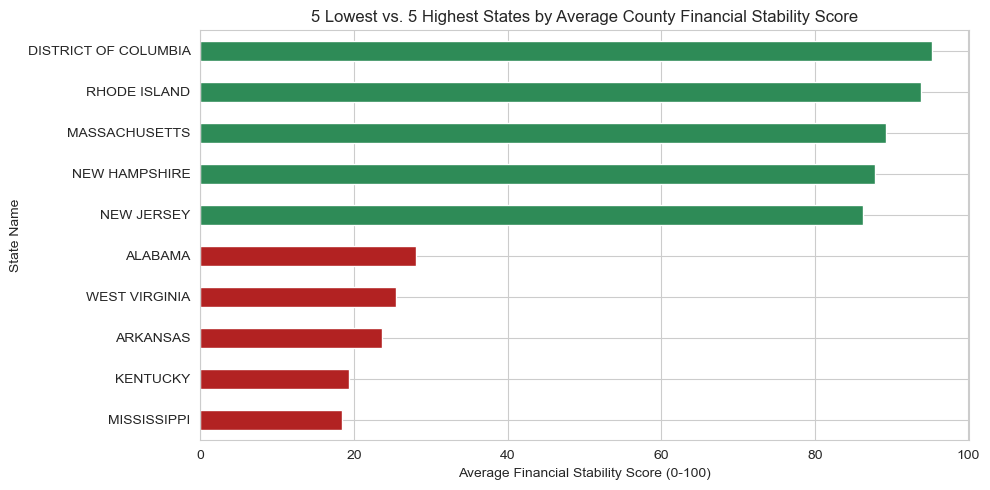

In [33]:
state_stability = clean.groupby("State Name")["stability_score"].mean().dropna().sort_values()
fig, ax = plt.subplots(figsize=(10, 5))
pd.concat([state_stability.head(5), state_stability.tail(5)]).plot(
    kind="barh", ax=ax, color=(["firebrick"] * 5 + ["seagreen"] * 5)
)
ax.set_title("5 Lowest vs. 5 Highest States by Average County Financial Stability Score")
ax.set_xlabel("Average Financial Stability Score (0-100)")
plt.tight_layout()
plt.show()

**Sanity check passed.** The top of the list is dominated by wealthy DC-suburb and NYC-metro counties (Loudoun, Arlington, Fairfax, and Falls Church, VA; Howard and Montgomery, MD; Nassau, NY) — all well-documented as among the highest-income counties in the U.S. The bottom is dominated by counties in Appalachian Kentucky, the Mississippi Delta, and West Virginia (including McDowell County, WV, frequently cited in poverty research as one of the poorest counties in the country). The state-level ranking also reproduces the income/unemployment geography found independently in Section 2.7 (Mississippi, Kentucky, Arkansas, West Virginia, and Alabama lowest; New Jersey, New Hampshire, Massachusetts, Rhode Island, and DC highest). This convergence across three independent views of the data (raw income, PCA, and now the composite score) is good evidence the score reflects something real rather than a modeling artifact.

### 7.3 A fragility / atypicality metric via distance-to-centroid

The composite score answers *"how prosperous is this county on average?"* It does not answer *"how structurally unusual is this county?"* — two very different questions. We answer the second with distance, in the standardized feature space, from each county to (a) its own cluster's center, and (b) the center of the most stable cluster.

Cluster 1 has the highest average stability score and is used as the reference archetype.


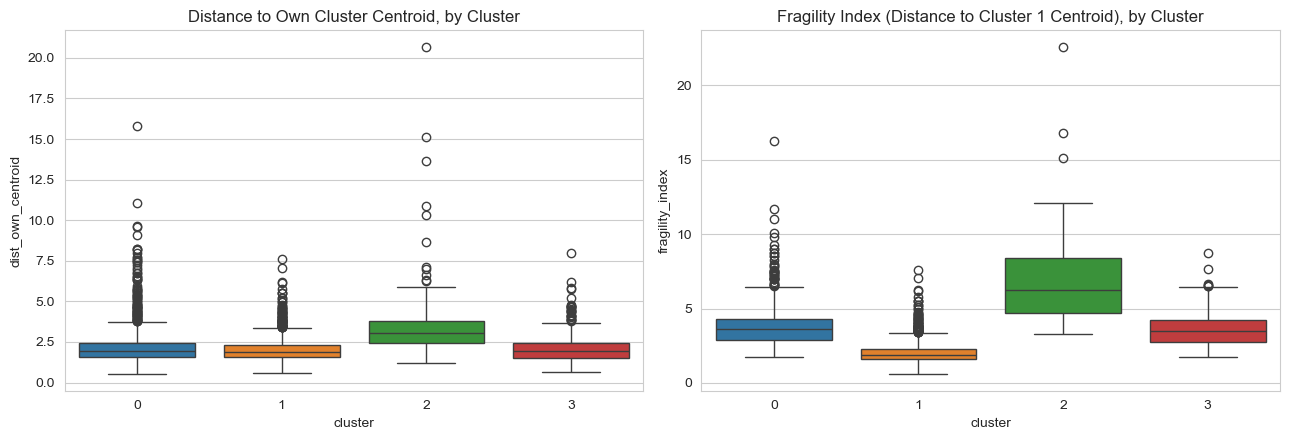

,dist_own_centroid,fragility_index
cluster,,
0,2.23,3.77
1,2.07,2.07
2,3.58,6.84
3,2.06,3.60


In [34]:
centers = kmeans.cluster_centers_

# (a) how atypical is a county relative to its own assigned group?
clean["dist_own_centroid"] = np.linalg.norm(X_scaled.values - centers[cluster_labels], axis=1)

# (b) how far is a county from the most stable archetype found by clustering?
stable_cluster = clean.groupby("cluster")["stability_score"].mean().idxmax()
print(f"Cluster {stable_cluster} has the highest average stability score and is used as the reference archetype.")
clean["fragility_index"] = np.linalg.norm(X_scaled.values - centers[stable_cluster], axis=1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.boxplot(data=clean, x="cluster", y="dist_own_centroid", hue="cluster", palette="tab10", legend=False, ax=axes[0])
axes[0].set_title("Distance to Own Cluster Centroid, by Cluster")
sns.boxplot(data=clean, x="cluster", y="fragility_index", hue="cluster", palette="tab10", legend=False, ax=axes[1])
axes[1].set_title(f"Fragility Index (Distance to Cluster {stable_cluster} Centroid), by Cluster")
plt.tight_layout()
plt.show()

clean.groupby("cluster")[["dist_own_centroid", "fragility_index"]].mean().round(2)

### 7.4 Combining score and fragility to find "hidden risk" counties

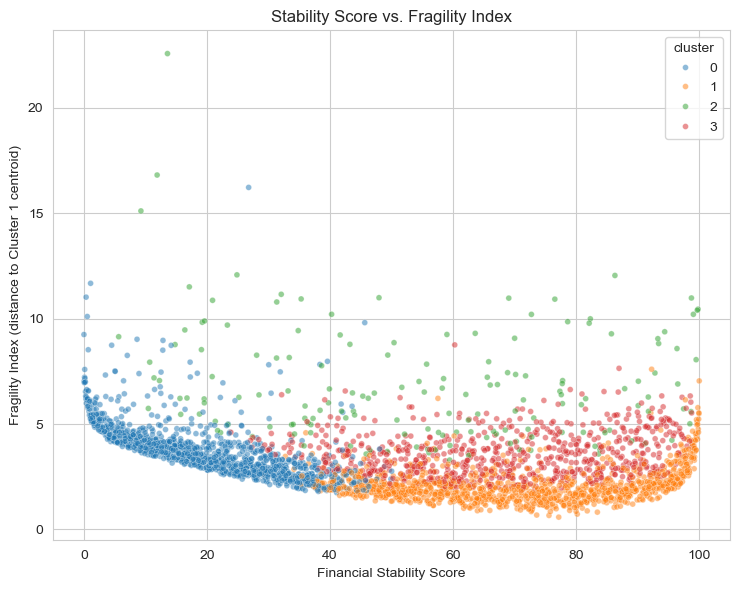

Correlation between stability_score and fragility_index: -0.306


In [35]:
fig, ax = plt.subplots(figsize=(7.5, 6))
sns.scatterplot(data=clean, x="stability_score", y="fragility_index", hue="cluster", palette="tab10", alpha=0.5, s=18, ax=ax)
ax.set_xlabel("Financial Stability Score")
ax.set_ylabel(f"Fragility Index (distance to Cluster {stable_cluster} centroid)")
ax.set_title("Stability Score vs. Fragility Index")
plt.tight_layout()
plt.show()

print("Correlation between stability_score and fragility_index:",
      round(clean["stability_score"].corr(clean["fragility_index"]), 3))

In [36]:
# "Hidden risk": counties that look fine on the composite score but are structurally atypical
median_score = clean["stability_score"].median()
q75_frag = clean["fragility_index"].quantile(0.75)
divergent = clean[(clean["stability_score"] >= median_score) & (clean["fragility_index"] >= q75_frag)].copy()

print(f"'Hidden risk' counties (above-median score, top-quartile fragility): "
      f"{len(divergent)} of {len(clean)} ({len(divergent)/len(clean)*100:.1f}%)")

print("\nShare of each cluster that qualifies as 'hidden risk':")
print((divergent["cluster"].value_counts() / clean["cluster"].value_counts() * 100).round(1).dropna().sort_values(ascending=False))

print("\nMost extreme divergent counties:")
divergent.sort_values("fragility_index", ascending=False)[
    ["State Name", "County Name", "stability_score", "fragility_index", "cluster"]
].head(10)

'Hidden risk' counties (above-median score, top-quartile fragility): 282 of 3154 (8.9%)

Share of each cluster that qualifies as 'hidden risk':
cluster
2    49.1
3    24.7
1     2.8
Name: count, dtype: float64

Most extreme divergent counties:


,State Name,County Name,stability_score,fragility_index,cluster
2568,TEXAS,CHAMBERS,86.303107,12.050686,2
1879,NEW YORK,RICHMOND,98.731769,10.981741,2
2917,VIRGINIA,SOUTHAMPTON,69.055168,10.974621,2
1926,NORTH CAROLINA,DARE,76.537730,10.926639,2
1867,NEW YORK,NEW YORK,99.809765,10.450274,2
2954,VIRGINIA,POQUOSON,99.682942,10.401050,2
1233,MASSACHUSETTS,NANTUCKET,99.048827,10.206982,2
271,COLORADO,FREMONT,72.733037,10.204123,2
2582,TEXAS,CORYELL,82.308180,9.992949,2
2891,VIRGINIA,MIDDLESEX,78.630311,9.856750,2


**A concrete example: Manhattan (New York County, NY).** It scores in the **99.8th percentile** on the Financial Stability Score — near the very top of the entire dataset — yet has one of the **highest fragility index values anywhere** (~10.5, over 5x the typical county), because its income-percentile columns (`P_less_30k`, `P_more_200`) are extreme even after our outlier cleaning. A composite-score-only view would call Manhattan an unambiguous success story; the fragility index says "structurally unlike anywhere else, worth a second look" regardless of whether that's genuine extreme income inequality or continued data noise. Several of the other most-divergent counties are similar edge cases — Nantucket, MA; Poquoson, VA; Richmond (Staten Island), NY — small, unusual, high-income enclaves rather than random data errors, which is itself informative.

## 8. Composite Score & Fragility Findings — In Plain English

**The Financial Stability Score works as a general-purpose ranking tool.** Because it collapses income, employment, unemployment, and youth credit health into a single 0–100 number, it reproduces every major geographic pattern already found in the raw EDA — DC suburbs and Northeastern states at the top, Appalachian and Mississippi Delta counties at the bottom — without needing to look at 11 separate variables. That consistency across three independent methods (raw EDA, PCA, and the composite score) is the main evidence it's trustworthy enough to use for ranking and prioritization.

**But the score alone has a blind spot, and that's exactly what the fragility index is for.** Cluster 1 (the high-income, dense-job-market group) has the *highest* average stability score (70.2), edging out even Cluster 3, the high-employment/high-QOL rural cluster (68.3) — because the composite score weights income and credit health more heavily than quality of life or employment rate specifically. That's a modeling choice worth being explicit about: **"financial stability" as scored here means income/credit capacity, not overall well-being.** A user who cares more about quality of life than income should weight PC2/PC3 differently, not just use PC1 alone.

**The fragility index adds information the score can't see on its own.** The correlation between the two is only **-0.31** — moderate, not strong — meaning a lot of variation in "how atypical is this county" is simply not captured by "how prosperous is this county on average." Cluster 2 (the small, statistically extreme group from Section 6) has by far the highest average fragility (6.84, roughly double every other cluster's average of ~2.1–3.8) despite a *middling* stability score (55.1) — this is the clearest proof that the two features measure genuinely different things. Practically: **282 counties (8.9% of the dataset)** score above the national median on stability yet sit in the riskiest quartile on fragility. Proportionally, this "hidden risk" pattern is most common inside Cluster 2 (about half of its counties qualify) but shows up meaningfully inside Cluster 3 too (~25% of its counties), meaning fragility isn't only a Cluster-2 phenomenon.

**Manhattan is the sharpest illustration of why both metrics matter together.** It's essentially a top-1% county by the composite score, but its fragility index puts it among the most structurally unusual counties in the entire dataset. Whether that reflects genuine extreme inequality (very plausible for Manhattan specifically) or continued measurement noise in the underlying percentile columns, a decision-maker relying on the stability score alone would never have flagged it for a closer look — which is the core argument for tracking fragility as a second, independent signal rather than folding everything into one number.

## 9. Final Report

### What this dataset is
`financial_sustainability.csv` contains economic and financial-health indicators — unemployment, income, job-market density, employment rate, income-percentile scores, a quality-of-life index, and youth credit metrics — for **3,154 U.S. counties**, listed once per city/place within each county (40,409 raw rows). The true unit of analysis is the **county**, not the city.

### Data quality
The dataset required real cleanup before it could be trusted: two exact duplicate rows, a `-8888` "missing value" sentinel left inside `QOL_index` for 52+ counties, ~35 counties with implausible extreme negative values in the income-percentile columns (`P_less_30k`, `P_more_200`), and a complete coverage gap for Connecticut and Puerto Rico on several core economic variables. All of these were identified and corrected (or explicitly flagged) before analysis, and are documented in Sections 2.5–2.6 above.

### What the exploratory analysis showed
Income, employment, and youth financial health move together in the way you'd expect economically — counties with more employment have higher incomes and financially healthier young residents. However, **local job-market size/density is a largely independent dimension** from unemployment: having lots of jobs nearby doesn't automatically translate into low unemployment for county residents. Income and unemployment both follow familiar U.S. geography, with the lowest incomes concentrated in the South/Appalachia and the lowest unemployment across the northern Great Plains and New England.

### What the clustering analysis showed
PCA confirmed the data has (at least) three separate underlying dimensions — general prosperity, local job-market density, and a residual "extreme value" dimension tied to the flagged outlier columns — rather than one simple good/bad spectrum. K-Means (k=4), cross-validated with hierarchical clustering and DBSCAN, split the 3,154 counties into four interpretable groups:

1. **Lower-Income, Lower-Employment Counties** (largest group) — furthest from financial security.
2. **High-Income, Dense Job-Market / Metro-Adjacent Counties** — highest pay and job access, but not the highest quality-of-life score.
3. **A small (~5%), statistically extreme group** whose defining feature is data instability rather than a real economic pattern — flagged for source verification rather than treated as a genuine archetype.
4. **High-Employment, High Quality-of-Life Rural Counties** — small job markets but the best employment rate, quality-of-life score, and youth credit outcomes of any group, concentrated in the farm belt (NE/KS/IA).

### What the derived score and fragility metrics showed
Turning PCA/clustering into two decision-ready features — a **Financial Stability Score** (0-100, from PC1) and a **Fragility Index** (distance to the most-stable cluster's centroid) — produced a score that independently reproduces the same income/unemployment geography found in the raw EDA (validating it), plus a genuinely new signal: fragility is only weakly correlated with the score itself (r ≈ -0.31), so **282 counties (8.9%)** look financially healthy on the composite score while still being structurally atypical enough to warrant a closer look. Manhattan is the sharpest example — a top-1% stability score paired with one of the highest fragility values in the dataset.

### Key takeaway
Financial sustainability in this dataset is **not a single "rich vs. poor" story**. A county can have a large, dense job market and still not have the best quality of life (Cluster 1), while a small rural county with very few local jobs can have the *best* employment rate and quality-of-life outcomes in the country (Cluster 3). And even a single well-built composite score can miss risk that a structural/distance-based metric catches — **use the two together, not the score alone.** Any policy or investment framing built on this data should treat "job availability," "income," and "resident well-being" as related but distinct levers, not proxies for one another.

### Using this for future insights on financial stability
This snapshot enables ranking and monitoring today, but not forecasting on its own — that requires either longitudinal data or a defined future outcome to predict. Three concrete next steps follow directly from the features built in Section 7:
- **Track counties over time.** If a future refresh of this dataset becomes available, recompute `stability_score` and `fragility_index` per county and watch for movement — a county's score or fragility level *changing* is a far stronger signal than its level in a single snapshot.
- **Monitor the fragility index as an early-warning list**, independent of the stability score. Counties with rising fragility, even at a stable or improving score, are the ones most likely to be missed by score-only reporting.
- **Use `stability_score`/`fragility_index` as predictors**, not just descriptive outputs — e.g. as features in a supervised model against a real future outcome (next year's unemployment, population change, tax base growth) once such a labeled target is available.

### Limitations & recommended next steps
- The ~5% "statistically extreme" cluster should be investigated at the source-data level before being used in any downstream decision — it may reflect a real (if rare) county profile, or it may simply be uncorrected estimation noise.
- Silhouette scores were modest, meaning the four groups are useful summaries of a continuous gradient, not hard, naturally-separated categories — treat cluster boundaries as soft.
- The Financial Stability Score reflects **income/employment/credit capacity specifically** (PC1's loadings), not overall well-being — Cluster 3's high quality-of-life/employment rate doesn't win it the top score, because the score wasn't built to weight those factors as heavily. State that definition explicitly whenever the score is shared with a non-technical audience.
- Connecticut and Puerto Rico are essentially unrepresented in any model built on this file; conclusions should not be extended to those areas without sourcing supplementary data.
- The dataset's non-standard, likely-transformed percentile columns (`P_less_30k`, `P_more_200`, `QOL_index`) would benefit from a data dictionary from the original source to confirm exactly how they were computed and what a "normal" range should look like — our -1000/-5000 cleaning thresholds were inferred from the data's own distribution, not a documented spec.